## 7. Granger Causality Screening

Granger tests are retained as predictive screens only. A significant result means past values of a predictor contain incremental predictive information for CPI inflation conditional on past CPI inflation. Granger causality is not structural or economic causality, especially for policy variables such as the RBA cash rate that also respond to inflation.

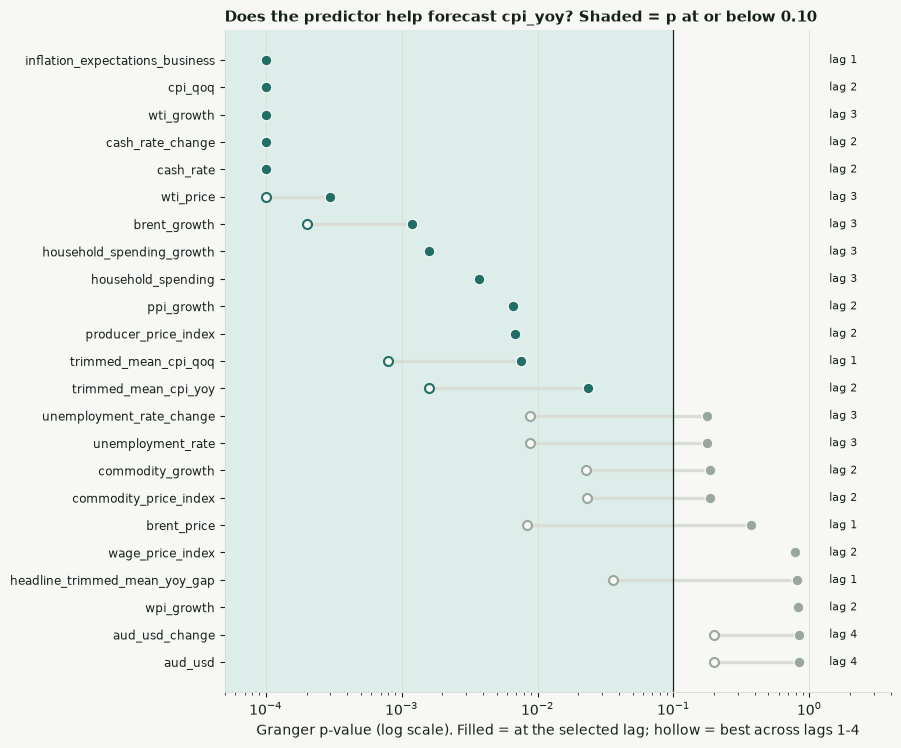

In [9]:
def compute_granger_screens(
    target: str,
    predictor_columns: list[str],
    target_stationary_values: pd.Series,
    best_predictive: pd.DataFrame,
    max_lag_limit: int = MAX_LAG,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, int]]:
    best_lags = dict(zip(best_predictive['variable'], best_predictive['lag_quarters']))

    def granger_screen(variable: str) -> dict[str, object]:
        x = stationary_series(variable).rename(variable)
        data = pd.concat([target_stationary_values.rename(target), x], axis=1).dropna()
        max_lag = min(max_lag_limit, max(1, len(data) // 10))
        selected_lag = int(best_lags.get(variable, 1))
        selected_lag = min(max(selected_lag, 1), max_lag)
        base_record = {
            'target': target,
            'variable': variable,
            'selected_lag': selected_lag,
            'granger_p_value': np.nan,
            'min_granger_p_value': np.nan,
            'tested_lags': '',
            'n_obs': len(data),
            'note': 'insufficient stationary observations',
            'p_values_by_lag': {},
        }
        if len(data) < 24 or data[variable].nunique() < 3:
            return base_record
        try:
            result = grangercausalitytests(data[[target, variable]], maxlag=max_lag, verbose=False)
            p_values = {lag: float(result[lag][0]['ssr_ftest'][1]) for lag in range(1, max_lag + 1)}
            base_record.update({
                'granger_p_value': p_values.get(selected_lag, np.nan),
                'min_granger_p_value': min(p_values.values()) if p_values else np.nan,
                'tested_lags': ', '.join(f'{lag}:{p_value:.3f}' for lag, p_value in p_values.items()),
                'note': 'screening signal only; not structural causality',
                'p_values_by_lag': p_values,
            })
            return base_record
        except Exception as exc:
            base_record['note'] = f'granger failed: {type(exc).__name__}'
            return base_record

    records = [granger_screen(column) for column in predictor_columns]
    granger_frame = pd.DataFrame([{key: value for key, value in record.items() if key != 'p_values_by_lag'} for record in records])
    lag_results = pd.DataFrame([
        {
            'target': record['target'],
            'variable': record['variable'],
            'lag_quarters': lag,
            'granger_p_value': p_value,
            'n_obs': record['n_obs'],
        }
        for record in records
        for lag, p_value in record.get('p_values_by_lag', {}).items()
    ])
    return granger_frame, lag_results, {variable: int(lag) for variable, lag in best_lags.items()}


def display_granger_screens(granger_frame: pd.DataFrame, lag_results: pd.DataFrame) -> None:
    with plt.rc_context(BOOK_STYLE):
        g = granger_frame.sort_values("granger_p_value", ascending=False).reset_index(drop=True)
        floor = 1e-4
        fig, ax = plt.subplots(figsize=(8.6, 0.3 * len(g) + 1.7))
        ax.axvspan(floor / 2, 0.10, color=ACCENT_SOFT, alpha=0.45, linewidth=0)
        ax.axvline(0.10, color=INK, linewidth=0.9)
        for y, r in g.iterrows():
            signal = r["granger_p_value"] <= 0.10
            lo, hi = sorted([max(r["min_granger_p_value"], floor), max(r["granger_p_value"], floor)])
            ax.plot([lo, hi], [y, y], color=GRID, linewidth=2.4, zorder=1)
            ax.scatter(max(r["min_granger_p_value"], floor), y, s=42, facecolor=PAPER, edgecolor=ACCENT if signal else MUTED,
                       linewidth=1.5, zorder=3)
            ax.scatter(max(r["granger_p_value"], floor), y, s=60, color=ACCENT if signal else MUTED, edgecolor=PAPER,
                       linewidth=1.0, zorder=4)
            ax.text(1.4, y, f"lag {int(r['selected_lag'])}", va="center", fontsize=8)
        ax.set_xscale("log")
        ax.set_xlim(floor / 2, 4)
        ax.set_yticks(g.index, g["variable"], fontsize=8.4)
        ax.set_xlabel("Granger p-value (log scale). Filled = at the selected lag; hollow = best across lags 1-4")
        ax.set_title(f"Does the predictor help forecast {g['target'].iloc[0]}? Shaded = p at or below 0.10", loc="left",
                     fontsize=11, fontweight="bold")
        ax.grid(axis="y", visible=False)
        plt.show()


granger, granger_lag_results, best_lag_lookup = compute_granger_screens(
    TARGET,
    CORRELATION_BASE_COLS,
    target_stationary,
    best_predictive_ccf,
)
display_granger_screens(granger, granger_lag_results)

**Interpretation.** Nearly every variable that showed a strong lead-lag correlation in §6
also survives the stricter Granger test: business inflation expectations (p=0.0000), the
cash rate and its change (p=0.0001), oil prices (`wti_growth` p=0.0001, `brent_growth`
p=0.0012), and household spending (p=0.0016–0.0037) all carry statistically significant
incremental predictive information for CPI beyond CPI's own history. The clear exception is
`aud_usd`: despite being tested at every lag, its Granger p-values range from 0.20 to 0.84 —
never close to significant — which is the concrete reason the exchange rate never makes it
into the candidate pool in §10/§11, despite being tested.